<a href="https://colab.research.google.com/github/NamithaDaney/CarPrice_Perdiction/blob/main/CarPrice_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Business Goal:**
 You are required to model the price of cars with the available independent variables. It
will be used by the management to understand how exactly the prices vary with the independent
variables. They can accordingly manipulate the design of the cars, the business strategy, etc., to meet
certain price levels. Further, the model will be a good way for the management to understand the pricing
dynamics of a new market.

In [622]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

**Loading and Preprocessing**

In [623]:
#load dataset
df = pd.read_csv('CarPrice_Assignment.csv')
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [624]:
df.shape

(205, 26)

In [625]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [626]:
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [627]:
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [628]:
df.duplicated().sum()

np.int64(0)

In [629]:
df.nunique()

,0
car_ID,205
symboling,6
CarName,147
fueltype,2
aspiration,2
doornumber,2
carbody,5
drivewheel,3
enginelocation,2
wheelbase,53


In [630]:
numeric_cols = [item for item in df.columns if df[item].dtype != 'O'] #numeric columns
print(numeric_cols)
categorical_cols = [item for item in df.columns if df[item].dtype == 'O'] # categorical columns
print(categorical_cols)

['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']
['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']


In [631]:
len(numeric_cols)

16

In [632]:
# Calculate correlation matrix for the whole dataframe
corr_matrix = df.corr(numeric_only=True)

price_corr = corr_matrix['price'].sort_values(ascending=False)
print(price_corr)


price               1.000000
enginesize          0.874145
curbweight          0.835305
horsepower          0.808139
carwidth            0.759325
carlength           0.682920
wheelbase           0.577816
boreratio           0.553173
carheight           0.119336
stroke              0.079443
compressionratio    0.067984
symboling          -0.079978
peakrpm            -0.085267
car_ID             -0.109093
citympg            -0.685751
highwaympg         -0.697599
Name: price, dtype: float64


In [633]:
df.drop(columns='car_ID',axis=1,inplace=True)

In [634]:
len(categorical_cols)

10

In [635]:
#delete CarName. Here we have to onlt predict the price not the car model name therefore deleted the column.
df.drop(['CarName'],axis=1,inplace=True)

In [636]:
categorical_cols.remove('CarName')

In [637]:
for col in categorical_cols:
    print(f'{col} unique values are {df[col].unique()} ')

fueltype unique values are ['gas' 'diesel'] 
aspiration unique values are ['std' 'turbo'] 
doornumber unique values are ['two' 'four'] 
carbody unique values are ['convertible' 'hatchback' 'sedan' 'wagon' 'hardtop'] 
drivewheel unique values are ['rwd' 'fwd' '4wd'] 
enginelocation unique values are ['front' 'rear'] 
enginetype unique values are ['dohc' 'ohcv' 'ohc' 'l' 'rotor' 'ohcf' 'dohcv'] 
cylindernumber unique values are ['four' 'six' 'five' 'three' 'twelve' 'two' 'eight'] 
fuelsystem unique values are ['mpfi' '2bbl' 'mfi' '1bbl' 'spfi' '4bbl' 'idi' 'spdi'] 


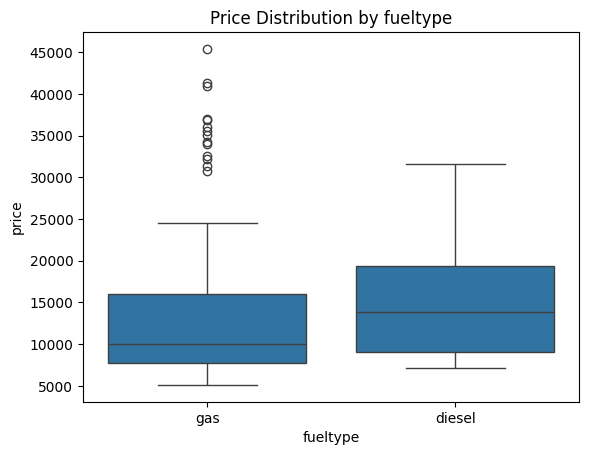

In [638]:
sns.boxplot(data=df, x='fueltype', y='price')
plt.title('Price Distribution by fueltype')
plt.show()



The boxplot reveals that diesel vehicles have a higher median price and overall distribution compared to gas vehicles, making them generally more expensive on average. However, the gas category contains a significant cluster of high-end outliers extending up to 45,000, indicating that the most premium or luxury vehicles in the dataset run on gas. This distinct variation in price spreads proves that fueltype is a statistically significant feature for predicting vehicle cost.



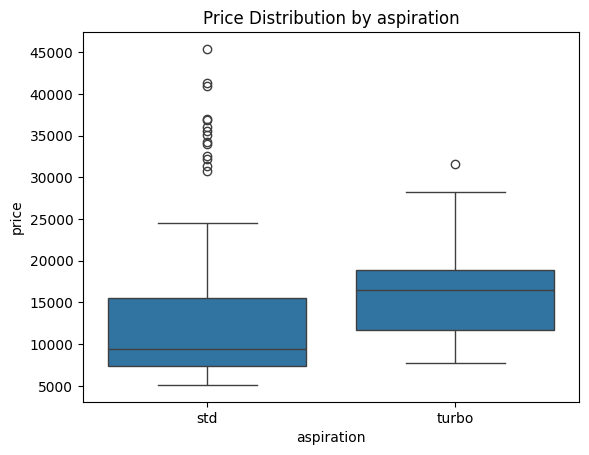

In [639]:
sns.boxplot(data=df, x='aspiration', y='price')
plt.title('Price Distribution by aspiration')
plt.show()

The boxplot shows that turbo vehicles command a noticeably higher median price and overall distribution than std aspirated cars. However, the std category feature has a massive trail of high-priced outliers extending past 45,000, representing elite luxury or sports vehicles with large non-turbo engines. The clear geometric difference between these two categories confirms that aspiration provides a strong predictive signal for car prices.



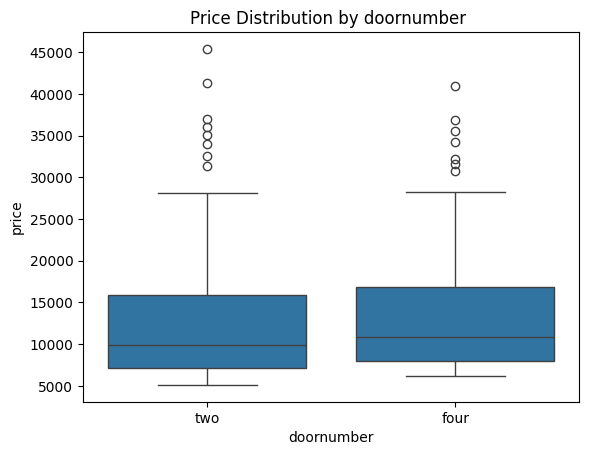

In [640]:
sns.boxplot(data=df, x='doornumber', y='price')
plt.title('Price Distribution by doornumber ')
plt.show()

In [641]:
#delete doornumber. Graph shows that there is no much difference in two or four number of doors effect in price  therefore deleted the column.
df.drop(['doornumber'],axis=1,inplace=True)

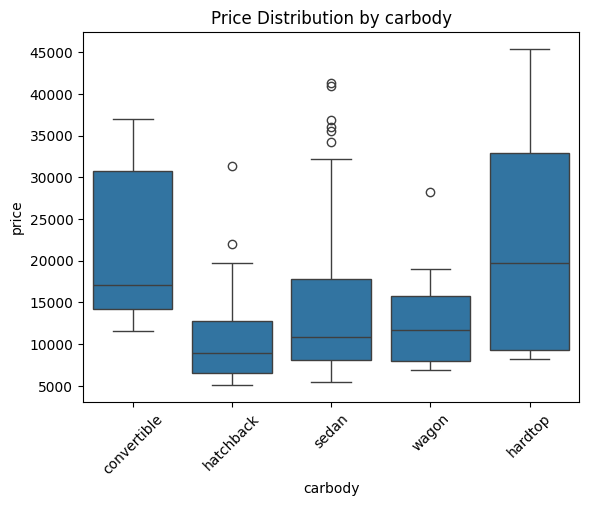

In [642]:
sns.boxplot(data=df, x='carbody', y='price')
plt.title('Price Distribution by carbody')
plt.xticks(rotation=45)
plt.show()

The boxplot shows that the convertible and hardtop have the highest median prices and widest pricing variations, while hatchback comes under the budget segment. This distinct separation in price distributions across styles proves that carbody carries a highly significant predictive signal for vehicle valuation

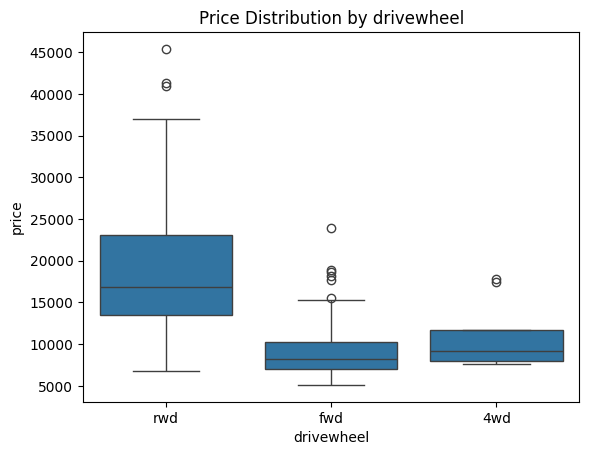

In [643]:
sns.boxplot(data=df, x='drivewheel', y='price')
plt.title('Price Distribution by drivewheel')
plt.show()

The boxplot shows that rwd vehicles has the higher median prices and wider price spreads compared to fwd and 4wd drivewheels. This strong distinction positions drivewheel as a highly impactful categorical feature for the prediction models.

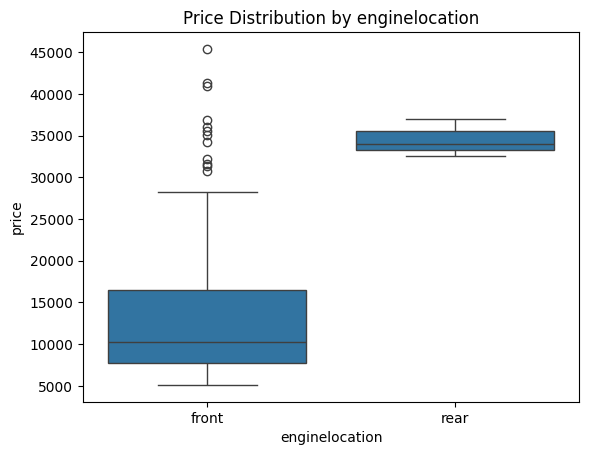

In [644]:
sns.boxplot(data=df, x='enginelocation', y='price')
plt.title('Price Distribution by enginelocation')
plt.show()

The boxplot reveals that vehicles with a rear engine location are high cost vehicles, it has higher and tighter price distribution than front engine vehicles. This stark separation in price brackets makes enginelocation an incredibly strong categorical predictor for the regression models.

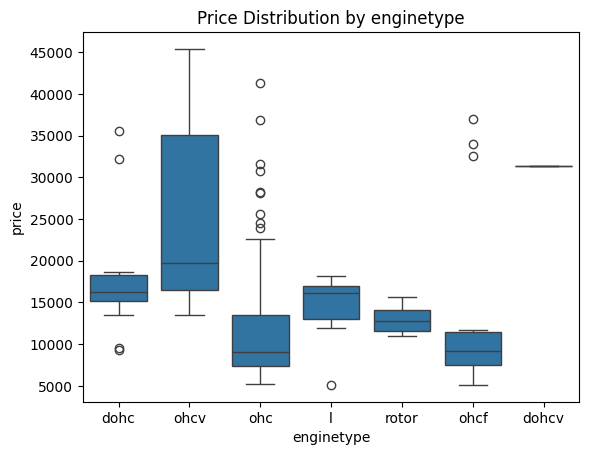

In [645]:
sns.boxplot(data=df, x='enginetype', y='price')
plt.title('Price Distribution by enginetype')
plt.show()

The boxplot shows that engine types like ohcv and dohcv have the highest median prices, whereas other enginetype like ohc form the core economy market. This clear variation in price distributions across categories makes enginetype a highly effective predictor for the regression models.

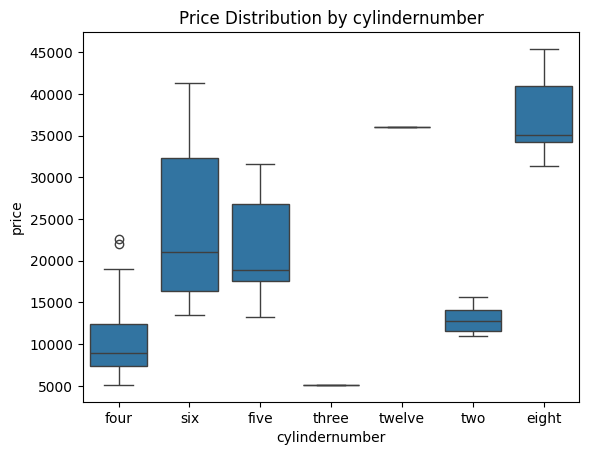

In [646]:
sns.boxplot(data=df, x='cylindernumber', y='price')
plt.title('Price Distribution by cylindernumber')
plt.show()

The boxplot reveals a clear trend where vehicles with higher cylinder numbers (like eight and twelve) has high prices, while three and four cylinders comes under the budget market. This strong step-like variation across segments confirms that cylindernumber is a relevant predictor for car valuation.

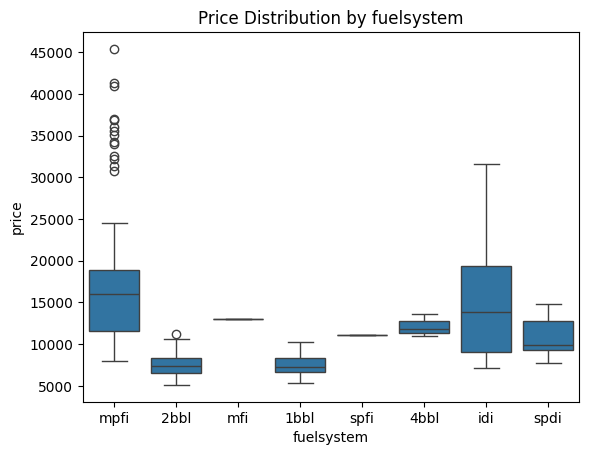

In [647]:
sns.boxplot(data=df, x='fuelsystem', y='price')
plt.title('Price Distribution by fuelsystem')
plt.show()

The boxplot shows that the fuel systems like mpfi and idi command higher medians and wider price distributions, with mpfi hosting a dense trail of high-end outliers up to 45,000. The fulesystems like 2bbl and 1bbl define the strict low-cost economy segment, making fuelsystem a highly predictive categorical feature.



In [648]:
new_df = pd.get_dummies(df, columns=categorical_cols.remove('doornumber'))

In [649]:
new_df.drop(columns=['fueltype', 'aspiration', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem'],axis=1,inplace=True, errors = "ignore")

In [650]:
new_df.shape

(205, 51)

In [651]:
new_df

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,...,cylindernumber_twelve,cylindernumber_two,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,False,False,False,False,False,False,False,True,False,False
1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,False,False,False,False,False,False,False,True,False,False
2,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,...,False,False,False,False,False,False,False,True,False,False
3,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,...,False,False,False,False,False,False,False,True,False,False
4,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,109.1,188.8,68.9,55.5,2952,141,3.78,3.15,9.5,...,False,False,False,False,False,False,False,True,False,False
201,-1,109.1,188.8,68.8,55.5,3049,141,3.78,3.15,8.7,...,False,False,False,False,False,False,False,True,False,False
202,-1,109.1,188.8,68.9,55.5,3012,173,3.58,2.87,8.8,...,False,False,False,False,False,False,False,True,False,False
203,-1,109.1,188.8,68.9,55.5,3217,145,3.01,3.40,23.0,...,False,False,False,False,False,True,False,False,False,False


In [652]:
numerical_columns = new_df.select_dtypes(include=[np.number]).columns
#print(numerical_columns)

cleaned_df = new_df.copy()

for col in numerical_columns:
    Q1 = cleaned_df[col].quantile(0.25)
    Q3 = cleaned_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    cleaned_df[col] = cleaned_df[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers capped smoothly!")

Outliers capped smoothly!


In [653]:
cleaned_df

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,...,cylindernumber_twelve,cylindernumber_two,fuelsystem_1bbl,fuelsystem_2bbl,fuelsystem_4bbl,fuelsystem_idi,fuelsystem_mfi,fuelsystem_mpfi,fuelsystem_spdi,fuelsystem_spfi
0,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,False,False,False,False,False,False,False,True,False,False
1,3,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,9.0,...,False,False,False,False,False,False,False,True,False,False
2,1,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,9.0,...,False,False,False,False,False,False,False,True,False,False
3,2,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,10.0,...,False,False,False,False,False,False,False,True,False,False
4,2,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,8.0,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,109.1,188.8,68.9,55.5,2952,141,3.78,3.15,9.5,...,False,False,False,False,False,False,False,True,False,False
201,-1,109.1,188.8,68.8,55.5,3049,141,3.78,3.15,8.7,...,False,False,False,False,False,False,False,True,False,False
202,-1,109.1,188.8,68.9,55.5,3012,173,3.58,2.87,8.8,...,False,False,False,False,False,False,False,True,False,False
203,-1,109.1,188.8,68.9,55.5,3217,145,3.01,3.40,10.6,...,False,False,False,False,False,True,False,False,False,False


In [654]:
cleaned_df.shape

(205, 51)

In [655]:
# Calculate correlation matrix for the cleaned dataframe
corr_matrix = cleaned_df.corr(numeric_only=True)

price_corr = corr_matrix['price'].sort_values(ascending=False)
print(price_corr)


price                    1.000000
curbweight               0.864597
enginesize               0.860063
horsepower               0.821715
carwidth                 0.783230
carlength                0.712455
drivewheel_rwd           0.673377
wheelbase                0.595909
boreratio                0.572685
fuelsystem_mpfi          0.545737
cylindernumber_six       0.490115
cylindernumber_eight     0.395134
enginetype_ohcv          0.345786
cylindernumber_five      0.306173
enginelocation_rear      0.304551
aspiration_turbo         0.238992
carbody_hardtop          0.194698
carbody_convertible      0.178912
enginetype_dohcv         0.174968
cylindernumber_twelve    0.174968
enginetype_dohc          0.169864
fuelsystem_idi           0.142586
fueltype_diesel          0.142586
carheight                0.142033
carbody_sedan            0.134120
stroke                   0.073830
enginetype_l             0.066849
enginetype_rotor         0.003973
cylindernumber_two       0.003973
fuelsystem_mfi

In [656]:
X = new_df.drop('price', axis = 1)
y = new_df['price']

In [667]:
#split data
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [668]:
#standardisation
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)

**Model Implementation**

In [659]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Support Vector Regressor": SVR(kernel='rbf', C=10000)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    results.append({'Model' : name, 'MSE' : mse, 'r2_score' :r2,'MAE' : mae})

results_df = pd.DataFrame(results).sort_values(by="r2_score", ascending=False)

print("FINAL MODEL PERFORMANCE COMPARISON")
print(results_df.to_string(index=False))

if results_df['r2_score'].max() > 0.8:
    best_model_name = results_df.loc[results_df['r2_score'].idxmax(), 'Model']
    print(f"\nThe best performed model is {best_model_name} because it is having the heighest r2_score .{results_df['r2_score'].max()}")


FINAL MODEL PERFORMANCE COMPARISON
                   Model          MSE  r2_score         MAE
           Random Forest 7.269867e+06  0.906094 1851.046256
       Gradient Boosting 7.672837e+06  0.900889 1771.259692
       Linear Regression 1.112531e+07  0.856293 2193.364475
           Decision Tree 1.156945e+07  0.850555 2204.012195
Support Vector Regressor 1.692733e+07  0.781347 2369.245084

The best performed model is Random Forest because it is having the heighest r2_score .0.9060939170876816


The best performed model is Random Forest because it is having the heighest r2_score .8937 or 89% accuracy.

In [660]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(random_state=42)

In [661]:
y_pred_rf = model.predict(X_test_scaled)

**Feature Importance Analysis**

In [662]:
rf_model.feature_importances_

array([1.25141580e-03, 1.29149269e-02, 7.59645397e-03, 1.48011552e-02,
       3.68915718e-03, 2.16283257e-01, 6.42598149e-01, 3.52388137e-03,
       3.10854835e-03, 2.64753768e-03, 2.47406160e-02, 6.74089176e-03,
       1.00349557e-02, 3.10996101e-02, 4.35107527e-04, 5.51730919e-04,
       9.99636743e-04, 9.67067537e-04, 7.38294747e-04, 2.33799665e-04,
       4.78193107e-04, 1.51440233e-03, 1.91105106e-04, 1.59735701e-04,
       2.52873938e-03, 6.10230802e-04, 6.00513247e-06, 7.18503144e-06,
       2.37323255e-04, 0.00000000e+00, 8.52520494e-06, 1.80270912e-03,
       6.23359616e-05, 6.45213732e-05, 3.92314246e-05, 2.99889137e-04,
       7.92073718e-04, 1.23972728e-03, 1.17270342e-03, 0.00000000e+00,
       6.64840047e-06, 3.32183872e-05, 1.96266675e-05, 4.91016194e-04,
       5.04351221e-05, 3.11240748e-04, 7.74203178e-06, 2.72919871e-03,
       1.19051976e-04, 6.09916078e-05])

In [669]:
#Identify the significant variables affecting car prices
rf_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

sorted_rf_features = rf_importances.sort_values(ascending=False)
print("Feature Importances (Random Forest):")
print(sorted_rf_features.head(10))

Feature Importances (Random Forest):
enginesize    0.642598
curbweight    0.216283
highwaympg    0.031100
horsepower    0.024741
carwidth      0.014801
wheelbase     0.012915
citympg       0.010035
carlength     0.007596
peakrpm       0.006741
carheight     0.003689
dtype: float64


**Hyperparameter Tuning**

In [664]:
param_grid = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [10, 15, None],
    'ccp_alpha': [0.0, 0.001], #0.001, 0.01, 0.1
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}


grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train_scaled, y_train)

best_rf_grid_model = grid_search.best_estimator_
best_rf_grid_params = grid_search.best_params_
best_rf_grid_score = grid_search.best_score_

print(f"Optimal Hyperparameters Found: {best_rf_grid_params}")
print(f"Best R2 Score: {best_rf_grid_score}")


Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Optimal Hyperparameters Found: {'ccp_alpha': 0.0, 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best R2 Score: 0.9092227608255982


In [665]:
random_search = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid, n_iter=10, cv=5, scoring='r2', n_jobs=-1, verbose=1)
random_search.fit(X_train_scaled, y_train)

best_rf_rand_model = random_search.best_estimator_
best_rf_rand_params = random_search.best_params_
best_rf_rand_score = random_search.best_score_

print(f"Optimal Hyperparameters Found: {random_search.best_params_}")
print(f"Best R2 Score: {best_rf_rand_score}")


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Optimal Hyperparameters Found: {'n_estimators': 150, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 10, 'ccp_alpha': 0.0}
Best R2 Score: 0.8997811069911489


In [666]:
tuned_predictions = grid_search.best_estimator_.predict(X_test_scaled)
tuned_r2 = r2_score(y_test, tuned_predictions)
tuned_mae = mean_absolute_error(y_test, tuned_predictions)
tuned_mse = mean_squared_error(y_test, tuned_predictions)

print(f"Tuned Model R2 Score: {tuned_r2}")
print(f"Tuned Model MAE: {tuned_mae}")
print(f"Tuned Model MSE: {tuned_mse}")

Tuned Model R2 Score: 0.9131102180781707
Tuned Model MAE: 1703.726357398374
Tuned Model MSE: 6726690.483108228


Hyperparameter tuning was successfully performed using GridSearchCV, which optimized the Random Forest model parameters gives 91% accuracy while make prediction on unseened data. This optimization caused the test R² score to increase significantly from 89.37% to 91.31%, while simultaneously dropping the average prediction error (MAE) by 288.15 units.

